<a href="https://colab.research.google.com/github/dr-koehler-ai/Heart-Failure-Clinical-Records-Dashboard-V1/blob/main/Heart_Failure_Clinical_Records_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Heart Failure Survival Prediction V2**

*Objective*

*   Predict Mortality using machine learning models

*Dataset*
*   299 patients
*   13 clinical features
*   binary outcome (target variable: death event)


*Workflow*
*   Data cleaning (V1)
*   EDA (V1)
*   Statistical Analysis (V1)
*   Logistic Regression (V1)
*   Machine Learning

*Clinical question*

Can clinical variables be used to predict mortality in heart failure patients, based on a simple baseline model?

In [23]:
# Heart Failure Clinical Records Dashboard (V2)
# =========================================

#Standard library

#Data manipulation
import kagglehub
from pathlib import Path
import pandas as pd
import numpy as np

#Data Visualization
import seaborn as sns
import matplotlib.pyplot as plt

#Statistics
from scipy import stats
from statistics import mean, stdev
from math import sqrt

# Data preprocessing
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.utils import resample

# Data modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import recall_score, accuracy_score, f1_score, precision_score

# =========================
# 1. Dataset Download
# =========================

from google.colab import drive
drive.mount("/content/drive")

dataset_path = Path("/content/drive/MyDrive/AI_Healthcare/Heart_Failure/heart_failure_clinical_records.csv")

data = pd.read_csv(dataset_path)

data.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Unnamed: 0,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,death_event
0,0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


As the independent variables are all continuous, **a Gaussian Naive Bayes Model** was selected for first analysis.

              precision    recall  f1-score   support

           0       0.75      0.98      0.85        51
           1       0.88      0.29      0.44        24

    accuracy                           0.76        75
   macro avg       0.81      0.64      0.64        75
weighted avg       0.79      0.76      0.72        75



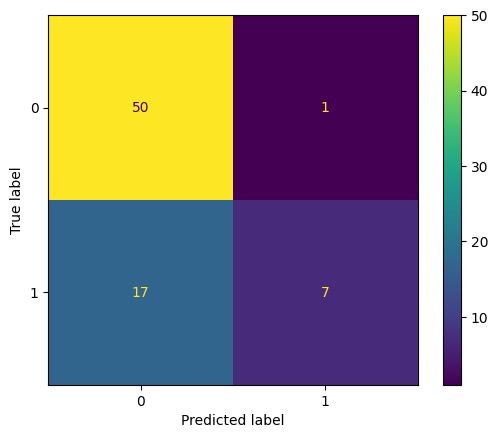

In [24]:
from sklearn.naive_bayes import GaussianNB

data.columns.tolist()

y = data["death_event"]
X = data[[
 'age',
 'ejection_fraction',
 'platelets',
 'serum_creatinine']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred = gnb.predict(X_test)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=gnb.classes_)
disp.plot()
plt.show()

**Data Scaling**


*   not much of a help

In [26]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

gnb_scaled = GaussianNB()
gnb_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = gnb_scaled.predict(X_test_scaled)

print(classification_report(y_test, y_pred_scaled))

              precision    recall  f1-score   support

           0       0.73      0.90      0.81        51
           1       0.58      0.29      0.39        24

    accuracy                           0.71        75
   macro avg       0.66      0.60      0.60        75
weighted avg       0.68      0.71      0.67        75

